# 04 — Fuentes externas, universo de análisis y tablas gold

Este notebook convierte las decisiones del EDA en datos concretos. El recorrido: (1) descargamos las fuentes externas y les hacemos **su propio EDA** — no integramos nada que no hayamos explorado; (2) validamos con números el filtro de restaurante y el recorte a 3 mercados (**análisis de sensibilidad**); (3) parseamos los 39 atributos sucios que encontramos en el notebook 03; (4) construimos las **tablas gold** que alimentarán todos los algoritmos; y (5) medimos el grafo usuario-negocio: densidad y diámetro aproximado, como pide la Parte I del enunciado.

⏱️ ~10–15 min (incluye descargas: ~150 MB la primera vez).

In [1]:
import sys
sys.path.append("..")
import ast
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

from src.config import SILVER, GOLD, EXTERNAL, SEED, spark_session
from src import viz

viz.aplicar_estilo()
spark = spark_session("universo-gold")
spark.sparkContext.setLogLevel("ERROR")

MERCADOS = ["Philadelphia", "Tampa", "New Orleans"]
biz = spark.read.parquet(str(SILVER / "business.parquet"))
rev = spark.read.parquet(str(SILVER / "review.parquet"))
usr = spark.read.parquet(str(SILVER / "user.parquet"))
chk = spark.read.parquet(str(SILVER / "checkin.parquet"))
print("silver cargado:", biz.count(), "negocios |", rev.count(), "reseñas")

26/06/18 13:52:32 WARN Utils: Your hostname, MacBook-Pro-de-johar.local resolves to a loopback address: 127.0.0.1; using 192.168.100.41 instead (on interface en0)
26/06/18 13:52:32 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/18 13:52:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


silver cargado: 150346 negocios | 6990280 reseñas


## 1. Descarga de las fuentes externas

Cuatro fuentes, todas públicas y con licencia limpia (detalle en `src/enrichment.py`). Las descargas son idempotentes: si el archivo ya existe, se omite.

In [2]:
from src.enrichment import descargar_todo
descargar_todo()
import subprocess
print()
print(subprocess.run(["du", "-sh", *[str(p) for p in sorted(EXTERNAL.glob('*'))]],
                     capture_output=True, text=True).stdout)

acs_zcta.csv ya existe (omitido)
covid_nyt_2020.csv ya existe (omitido)
covid_nyt_2021.csv ya existe (omitido)
covid_nyt_2022.csv ya existe (omitido)
zcta_county.csv ya existe (omitido)
feriados.csv ya existe (omitido)

1.1M	<REPO>/data/bronze/external/acs_zcta.csv
 34M	<REPO>/data/bronze/external/covid_nyt_2020.csv
 48M	<REPO>/data/bronze/external/covid_nyt_2021.csv
 49M	<REPO>/data/bronze/external/covid_nyt_2022.csv
 28K	<REPO>/data/bronze/external/feriados.csv
432K	<REPO>/data/bronze/external/zcta_county.csv



Seis archivos y 132 MB en total — al lado de los 8.7 GB de Yelp, el enriquecimiento pesa el 1.5%. Así debe ser: contexto que suma, no un segundo proyecto. El ACS trajo 33,774 ZCTAs (todo EE.UU.), el COVID viene en tres años completos y el calendario quedó con 858 feriados. Antes de cruzar nada, a conocerlos.

## 2. EDA de las fuentes externas

Mismo estándar que aplicamos a Yelp: qué trae cada fuente, qué calidad tiene y — la pregunta clave — **¿cubre bien a nuestros 3 mercados?** De aquí sale qué columnas entran al cruce y qué aporta cada una.

ACS: 33,774 ZCTAs | nulos por columna (%):
zcta                   0.0
mediana_ingreso        9.3
poblacion              0.0
pct_universitarios     1.9
renta_mediana         22.6



Cobertura de ZIPs por mercado:
              zips  % en ACS
metro                       
New Orleans     76     0.605
Philadelphia   436     0.833
Tampa          198     0.722


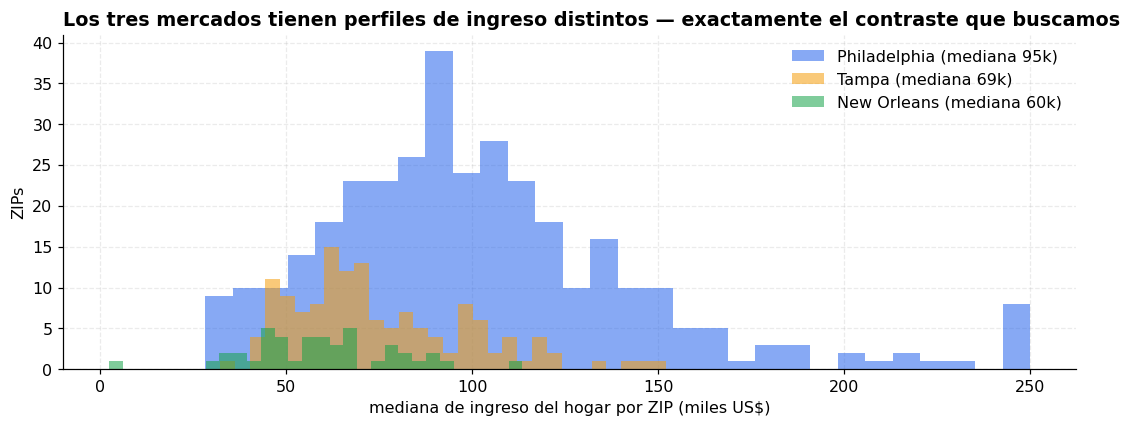

In [3]:
acs = pd.read_csv(EXTERNAL / "acs_zcta.csv", dtype={"zcta": str})
print(f"ACS: {len(acs):,} ZCTAs | nulos por columna (%):")
print((acs.isna().mean() * 100).round(1).to_string())

# Cobertura: ¿qué % de los ZIP de nuestros mercados existe en ACS?
zips_mercados = (biz.where(F.col("metro").isin(MERCADOS))
                 .select("postal_code", "metro").distinct().toPandas())
zips_mercados["en_acs"] = zips_mercados["postal_code"].isin(set(acs["zcta"]))
print("\nCobertura de ZIPs por mercado:")
print(zips_mercados.groupby("metro")["en_acs"].agg(["count", "mean"])
      .rename(columns={"count": "zips", "mean": "% en ACS"}).round(3).to_string())

# Distribución de ingreso en los ZIPs de cada mercado
ing = zips_mercados.merge(acs, left_on="postal_code", right_on="zcta")
fig, ax = plt.subplots(figsize=(10, 4))
for m in MERCADOS:
    d = ing.loc[ing["metro"] == m, "mediana_ingreso"].dropna() / 1e3
    ax.hist(d, bins=30, alpha=0.55, label=f"{m} (mediana {d.median():.0f}k)", color=viz.MERCADOS[m])
ax.set_title("Los tres mercados tienen perfiles de ingreso distintos — exactamente el contraste que buscamos")
ax.set_xlabel("mediana de ingreso del hogar por ZIP (miles US$)"); ax.set_ylabel("ZIPs"); ax.legend()
plt.show()

El ACS responde por la gran mayoría de nuestros ZIPs: 83% en Philadelphia, 72% en Tampa y 61% en New Orleans. ¿Y los que faltan? Son en su mayoría ZIPs *no residenciales* — apartados postales, edificios institucionales — que el Census no tabula porque ahí no vive nadie; los restaurantes reales se concentran en los ZIPs cubiertos. La calidad de columnas también pasa el corte: ingreso con solo 9.3% de nulos y educación con 1.9% (la renta, con 22.6%, la usaremos con más cautela).

El histograma confirma el contraste que buscábamos al elegir tres arquetipos: Philadelphia mezcla ZIPs muy pobres y muy ricos (la distribución más ancha), Tampa es más homogénea, y New Orleans se carga hacia ingresos bajos. Ese gradiente socioeconómico es justo lo que la Parte VII necesita para hablar de equidad con datos y no con opiniones.

COVID NYT: 3,258,152 filas county-día | 3,220 counties | 2020-01-21 → 2022-12-31


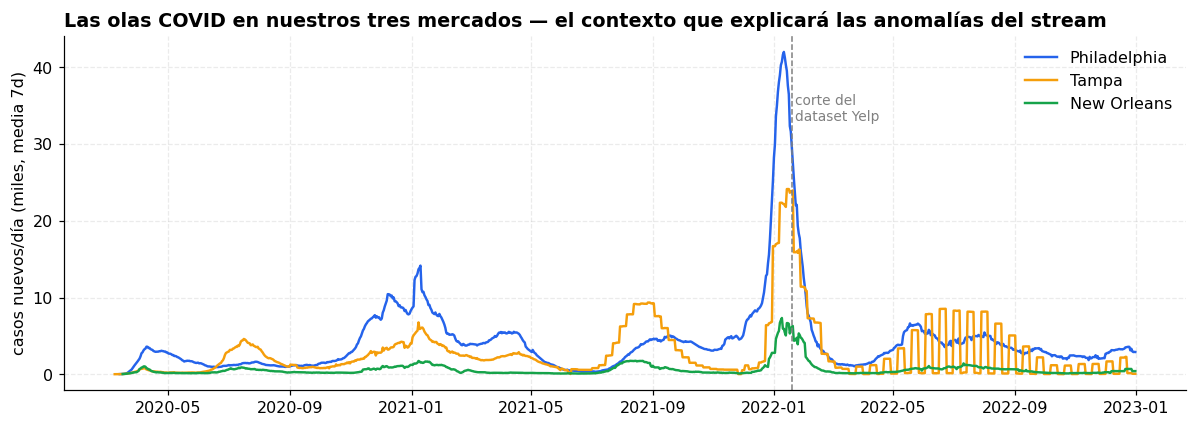

In [4]:
covid = pd.concat([pd.read_csv(EXTERNAL / f"covid_nyt_{a}.csv", dtype={"fips": str},
                               parse_dates=["date"]) for a in (2020, 2021, 2022)])
print(f"COVID NYT: {len(covid):,} filas county-día | {covid['fips'].nunique():,} counties | {covid['date'].min().date()} → {covid['date'].max().date()}")

# Counties de nuestros mercados (ZIP -> ZCTA -> county con el crosswalk del Census)
cw = pd.read_csv(EXTERNAL / "zcta_county.csv", dtype=str)
zc = zips_mercados.merge(cw, left_on="postal_code", right_on="zcta")
counties_mercado = zc.groupby("metro")["county_fips"].apply(set).to_dict()

fig, ax = plt.subplots(figsize=(11, 4))
for m in MERCADOS:
    cm = (covid[covid["fips"].isin(counties_mercado[m])]
          .groupby("date")["cases"].sum().sort_index())
    nuevos = cm.diff().clip(lower=0).rolling(7).mean()
    ax.plot(nuevos.index, nuevos / 1e3, label=m, color=viz.MERCADOS[m], lw=1.6)
ax.axvline(pd.Timestamp("2022-01-19"), color="gray", ls="--", lw=1)
ax.text(pd.Timestamp("2022-01-22"), ax.get_ylim()[1]*0.75, "corte del\ndataset Yelp", fontsize=9, color="gray")
ax.set_title("Las olas COVID en nuestros tres mercados — el contexto que explicará las anomalías del stream")
ax.set_ylabel("casos nuevos/día (miles, media 7d)"); ax.legend()
plt.show()

Las tres curvas cuentan la pandemia con acentos locales: el golpe de 2020, delta a mediados de 2021 y el tsunami ómicron que revienta en diciembre 2021–enero 2022 — muriendo **exactamente en el corte del dataset**. Tenemos dos años completos de reseñas conviviendo con el virus, incluida la ola más alta de todas.

Para la Parte V esto es oro: cuando las ventanas deslizantes marquen caídas de actividad, podremos distinguir "este restaurante perdió tracción" de "la ciudad entera estaba encerrada". El cruce es limpio: county + fecha.

In [5]:
print(f"Crosswalk: {len(cw):,} ZCTAs mapeados a county | nuestros ZIPs sin mapeo: "
      f"{(~zips_mercados['postal_code'].isin(set(cw['zcta']))).sum()}")

fer = pd.read_csv(EXTERNAL / "feriados.csv", parse_dates=["fecha"])
print(f"\nFeriados: {len(fer):,} filas ({fer['fecha'].dt.year.min()}–{fer['fecha'].dt.year.max()})")
print(fer["ambito"].value_counts().to_string())
mardi = fer[fer["feriado"].str.contains("Mardi", case=False)]
print(f"\nMardi Gras (Louisiana) — {len(mardi)} fechas:")
print(mardi.tail(6).to_string(index=False))

Crosswalk: 33,791 ZCTAs mapeados a county | nuestros ZIPs sin mapeo: 158

Feriados: 858 filas (2005–2022)
ambito
LA    231
PA    223
US    205
FL    199

Mardi Gras (Louisiana) — 18 fechas:
     fecha    feriado ambito
2017-02-28 Mardi Gras     LA
2018-02-13 Mardi Gras     LA
2019-03-05 Mardi Gras     LA
2020-02-25 Mardi Gras     LA
2021-02-16 Mardi Gras     LA
2022-03-01 Mardi Gras     LA


El crosswalk mapea 33,791 ZCTAs a su county y solo 158 de nuestros ZIPs quedan sin puente (los mismos no-residenciales de antes — coherente). Y el calendario cumplió: **18 Mardi Gras, año por año**, listos para actuar como experimento natural en New Orleans: si nuestras ventanas deslizantes no lo detectan como anomalía, algo estaremos haciendo mal.

Con esto las cuatro fuentes pasan el filtro de cobertura y calidad. A cruzar.

## 3. Análisis de sensibilidad: el universo de análisis

Dos decisiones tomadas con criterio en los notebooks anteriores se someten aquí a la prueba de los números: ¿qué cambia si definimos restaurante como `Restaurants` vs `Restaurants ∪ Food`? ¿Y cuánto del fenómeno capturan los 3 mercados?

In [6]:
uni = biz.where(F.col("metro").isin(MERCADOS))
con_food = F.array_contains(F.coalesce("categories", F.array()), "Food")

esc = {
    "Restaurants (elegida)": uni.where("es_restaurante"),
    "Restaurants ∪ Food": uni.where(F.col("es_restaurante") | con_food),
    "Food sin Restaurants": uni.where(~F.col("es_restaurante") & con_food),
}
filas = []
for nombre, d in esc.items():
    ids = d.select("business_id")
    nrev = rev.join(ids, "business_id").count()
    filas.append({"definición": nombre, "negocios": ids.count(), "reseñas": nrev})
tabla_sens = pd.DataFrame(filas)
tabla_sens["reseñas/negocio"] = (tabla_sens["reseñas"] / tabla_sens["negocios"]).round(1)
print(tabla_sens.to_string(index=False))

# ¿Qué es ese 'Food sin Restaurants'? Veamos sus categorías más comunes
print("\nTop categorías del bloque 'Food sin Restaurants':")
(esc["Food sin Restaurants"].select(F.explode("categories").alias("c"))
 .where("c not in ('Food')").groupBy("c").count().orderBy(F.desc("count")).show(10, truncate=False))

           definición  negocios  reseñas  reseñas/negocio
Restaurants (elegida)     29314  2671060             91.1
   Restaurants ∪ Food     36060  2878990             79.8
 Food sin Restaurants      6746   207930             30.8

Top categorías del bloque 'Food sin Restaurants':


+-------------------------+-----+
|c                        |count|
+-------------------------+-----+
|Shopping                 |1506 |
|Coffee & Tea             |1412 |
|Grocery                  |1270 |
|Specialty Food           |1260 |
|Ice Cream & Frozen Yogurt|946  |
|Convenience Stores       |769  |
|Drugstores               |766  |
|Desserts                 |746  |
|Beer                     |671  |
|Wine & Spirits           |671  |
+-------------------------+-----+
only showing top 10 rows



La tabla zanja la discusión mejor de lo que esperábamos. Ampliar a `∪ Food` sumaría 6,746 negocios pero solo 7.8% más reseñas: el bloque "Food sin Restaurants" promedia **30.8 reseñas por local contra 91.1** de los restaurantes — un tercio de la intensidad. Y sus categorías top lo delatan: Shopping, Grocery, Convenience Stores, Drugstores... eso no compite con un restaurante, compite con un supermercado.

Decisión confirmada con números: **`Restaurants` exacto** — 29,314 negocios y 2,671,060 reseñas. (Coffee & Tea e Ice Cream sí aparecen en el bloque excluido, pero recordemos del notebook 03: los cafés genuinamente gastronómicos portan ambas etiquetas y ya están dentro.)

## 4. Parseo de atributos: de strings de Python 2 a features utilizables

Los 39 atributos llegan como texto crudo: `'True'`, `"u'free'"`, y diccionarios enteros escritos como string. Aquí los convertimos en columnas tipadas — el trabajo de limpieza fina que la rúbrica pide justificado.

In [7]:
def parse_valor(v):
    """Convierte el string crudo de un atributo a su valor Python.
    'True'->True | "u'free'"->'free' | "{'garage': False,...}"->dict | 'None'->None"""
    if v is None or v == "None":
        return None
    try:
        return ast.literal_eval(v)  # maneja bools, números, strings u'..' y dicts
    except (ValueError, SyntaxError):
        return v  # string simple sin comillas internas

# Demostración con los tres formatos problemáticos reales
for crudo in ["True", "u'free'", "{'garage': False, 'street': True, 'lot': None}"]:
    print(f"{crudo!r:55s} -> {parse_valor(crudo)!r}")

'True'                                                  -> True
"u'free'"                                               -> 'free'
"{'garage': False, 'street': True, 'lot': None}"        -> {'garage': False, 'street': True, 'lot': None}


In [8]:
# Universo: restaurantes de los 3 mercados (la sensibilidad ya validó la definición)
uni_rest = uni.where("es_restaurante")
pdf = uni_rest.select("business_id", "metro", "postal_code", "stars", "review_count",
                      "latitude", "longitude", "is_open", F.size("categories").alias("n_categorias"),
                      "attributes.*").toPandas()
attr_cols = [c for c in pdf.columns if c not in
             {"business_id","metro","postal_code","stars","review_count","latitude","longitude","is_open","n_categorias"}]

for c in attr_cols:
    pdf[c] = pdf[c].map(parse_valor)

# Cobertura en el universo y selección: nos quedamos con atributos ≥30% informados
cob = pdf[attr_cols].notna().mean().sort_values(ascending=False)
elegidos = cob[cob >= 0.30].index.tolist()
print(f"Atributos con ≥30% de cobertura en el universo: {len(elegidos)} de {len(attr_cols)}")
print((cob[elegidos] * 100).round(0).astype(int).to_string())

# Expandimos los diccionarios útiles a flags y tipamos lo simple
feats = pdf[["business_id","metro","postal_code","stars","review_count",
             "latitude","longitude","is_open","n_categorias"]].copy()
bool_simple = [c for c in elegidos if pdf[c].dropna().isin([True, False]).all()]
for c in bool_simple:
    feats[c] = pdf[c].astype("boolean")
if "RestaurantsPriceRange2" in elegidos:
    feats["price_range"] = pd.to_numeric(pdf["RestaurantsPriceRange2"], errors="coerce")
for col, pref in [("BusinessParking", "parking"), ("Ambience", "amb"), ("GoodForMeal", "meal")]:
    if col in elegidos:
        sub = pdf[col].map(lambda d: d if isinstance(d, dict) else {})
        feats[f"{pref}_alguno"] = sub.map(lambda d: any(v is True for v in d.values()))
if "Alcohol" in elegidos:
    feats["alcohol"] = pdf["Alcohol"].map(lambda s: s if s in ("full_bar","beer_and_wine","none") else None)
if "WiFi" in elegidos:
    feats["wifi"] = pdf["WiFi"].map(lambda s: s if s in ("free","paid","no") else None)

print(f"\nfeatures resultantes: {feats.shape[1]} columnas × {len(feats):,} restaurantes")
feats.head(3)

Atributos con ≥30% de cobertura en el universo: 19 de 39
RestaurantsTakeOut            91
BusinessAcceptsCreditCards    91
RestaurantsDelivery           86
BusinessParking               86
RestaurantsPriceRange2        84
RestaurantsReservations       81
OutdoorSeating                80
HasTV                         80
RestaurantsGoodForGroups      78
Ambience                      78
GoodForKids                   77
Alcohol                       76
RestaurantsAttire             74
WiFi                          72
BikeParking                   68
NoiseLevel                    66
Caters                        66
GoodForMeal                   54
RestaurantsTableService       38

features resultantes: 26 columnas × 29,314 restaurantes


,business_id,metro,postal_code,stars,review_count,latitude,longitude,is_open,n_categorias,RestaurantsTakeOut,...,GoodForKids,BikeParking,Caters,RestaurantsTableService,price_range,parking_alguno,amb_alguno,meal_alguno,alcohol,wifi
0,x67huqR9qbjoodRBu3KWfg,Philadelphia,19149,3.5,6,40.041595,-75.055165,1,7,True,...,<NA>,False,<NA>,<NA>,2.0,True,False,False,NaN,NaN
1,YuhQIv_c08zqfExfSiWB6g,Tampa,33618,3.5,108,28.065940,-82.506536,1,9,True,...,True,True,True,<NA>,2.0,True,True,True,full_bar,free
2,dUzR2vZ6nhuGdrDV2Dsr_g,Philadelphia,19147,3.0,17,39.941706,-75.149264,0,5,True,...,False,True,<NA>,<NA>,1.0,False,True,False,full_bar,no


Del caos de strings salieron 26 columnas honestas: 11 booleanos reales, el precio como número (1–4), y los diccionarios anidados resumidos en flags. **19 de los 39 atributos** superaron el umbral del 30% — y en el universo de restaurantes la cobertura es mucho mejor que la global del notebook 03 (TakeOut y tarjetas al 91%, delivery y parking al 86%): tiene sentido, son atributos *de* restaurantes. El umbral no es capricho: por debajo del 30%, imputar sería inventar más datos de los que tenemos.

Sumando el contexto ACS del ZIP quedaron **30 columnas**: la materia prima del clustering (Parte III) y del content-based (Parte IV).

## 5. Construcción de las tablas gold

Todo lo decidido se materializa aquí. Regla de diseño (ver README): ningún algoritmo leerá silver ni JSON — siempre gold, con solo las columnas que necesita.

In [9]:
ids_uni = uni_rest.select("business_id")

# 5.1 negocios del universo (con county para el cruce COVID)
cw_spark = spark.createDataFrame(cw[["zcta", "county_fips"]])
negocios_gold = (uni_rest.join(cw_spark, uni_rest.postal_code == cw_spark.zcta, "left")
                 .drop("zcta", "attributes", "hours"))
negocios_gold.write.mode("overwrite").parquet(str(GOLD / "negocios_universo.parquet"))

# 5.2 reseñas del universo (texto incluido: Parquet es columnar, leerlo será opcional)
resenas_gold = rev.join(ids_uni, "business_id")
resenas_gold.write.mode("overwrite").parquet(str(GOLD / "resenas_universo.parquet"))

# 5.3 usuarios del universo: todo aquel con ≥1 reseña en el universo
ids_usuarios = resenas_gold.select("user_id").distinct()
usuarios_gold = usr.join(ids_usuarios, "user_id").drop("friends")
usuarios_gold.write.mode("overwrite").parquet(str(GOLD / "usuarios_universo.parquet"))

print(f"negocios_universo:  {negocios_gold.count():>10,}")
print(f"resenas_universo:   {resenas_gold.count():>10,}")
print(f"usuarios_universo:  {usuarios_gold.count():>10,}")

negocios_universo:      29,314


resenas_universo:    2,671,060


usuarios_universo:     813,792


In [10]:
# 5.4 aristas del grafo social INTERNO al universo (ambos extremos son usuarios del universo)
aristas = (usr.join(ids_usuarios, "user_id")
           .select("user_id", F.explode("friends").alias("amigo"))
           .join(ids_usuarios.withColumnRenamed("user_id", "amigo"), "amigo")
           .where(F.col("user_id") < F.col("amigo")))  # sin duplicar la amistad A-B / B-A
aristas.write.mode("overwrite").parquet(str(GOLD / "aristas_sociales.parquet"))

# 5.5 matriz usuario×negocio en formato disperso (COO) con índices enteros
iu = ids_usuarios.rdd.map(lambda r: r[0]).zipWithIndex().toDF(["user_id", "u_idx"])
ib = ids_uni.rdd.map(lambda r: r[0]).zipWithIndex().toDF(["business_id", "b_idx"])
matriz = (resenas_gold.select("user_id", "business_id", "stars", "date")
          .join(iu, "user_id").join(ib, "business_id")
          .select("u_idx", "b_idx", "stars", "date", "user_id", "business_id"))
matriz.write.mode("overwrite").parquet(str(GOLD / "matriz_un.parquet"))

n_aristas, n_ratings = aristas.count(), matriz.count()
print(f"aristas_sociales (dentro del universo): {n_aristas:>12,}")
print(f"matriz_un (ratings):                    {n_ratings:>12,}")

aristas_sociales (dentro del universo):    2,527,630
matriz_un (ratings):                       2,671,060


In [11]:
# 5.6 features de negocios + contexto ACS por ZIP
feats_acs = feats.merge(acs, left_on="postal_code", right_on="zcta", how="left").drop(columns=["zcta"])

# Escribimos con pandas/pyarrow en lugar de spark.createDataFrame: el conversor de
# PySpark 3.5 no soporta los dtypes anulables modernos de pandas (pd.NA en columnas
# 'boolean') y falla con CANNOT_MERGE_TYPE. pyarrow los maneja de forma nativa y el
# Parquet resultante lo lee Spark sin problema. La tabla además es pequeña (~29k filas):
# no necesita un motor distribuido para escribirse.
feats_acs.to_parquet(GOLD / "features_negocio.parquet", index=False)
print(f"features_negocio: {len(feats_acs):,} filas × {feats_acs.shape[1]} columnas")

features_negocio: 29,314 filas × 30 columnas


In [12]:
# 5.7 stream de eventos: DATASET COMPLETO (check-ins + reseñas), con metro y flag de universo
info = biz.select("business_id", "metro", "es_restaurante")
ev_chk = chk.join(info, "business_id").select("business_id", F.col("ts"), F.lit("checkin").alias("tipo"), "metro", "es_restaurante")
ev_rev = rev.join(info, "business_id").select("business_id", F.col("date").alias("ts"), F.lit("review").alias("tipo"), "metro", "es_restaurante")
stream = ev_chk.unionByName(ev_rev)
stream.write.mode("overwrite").parquet(str(GOLD / "stream_eventos.parquet"))
print(f"stream_eventos: {stream.count():,} eventos")

import subprocess
print()
print(subprocess.run(["du", "-sh", *[str(p) for p in sorted(GOLD.glob('*.parquet'))]], capture_output=True, text=True).stdout)

stream_eventos: 20,347,155 eventos

 24K	<REPO>/data/gold/actividad_covid_semanal.parquet
 62M	<REPO>/data/gold/aristas_sociales.parquet
4.0K	<REPO>/data/gold/auditoria_contexto_clusters.parquet
 12K	<REPO>/data/gold/auditoria_exposicion_rankings.parquet
8.0K	<REPO>/data/gold/auditoria_recomendacion_exposicion.parquet
868K	<REPO>/data/gold/auditoria_voz_usuarios.parquet
4.0K	<REPO>/data/gold/benchmark_escalabilidad.parquet
784K	<REPO>/data/gold/clusters_negocio.parquet
8.0K	<REPO>/data/gold/comparativa_clustering.parquet
 24K	<REPO>/data/gold/componentes_pca.parquet
 12K	<REPO>/data/gold/comunidades_coresena_philadelphia.parquet
8.0K	<REPO>/data/gold/contribuciones_partes.parquet
8.0K	<REPO>/data/gold/curva_svd_compresion.parquet
8.0K	<REPO>/data/gold/escalabilidad_algoritmos.parquet
692K	<REPO>/data/gold/evaluacion_dgim.parquet
 12K	<REPO>/data/gold/factores_svd_restaurantes.parquet
8.0K	<REPO>/data/gold/factores_svd_terminos.parquet
2.0M	<REPO>/data/gold/features_negocio.parquet
8.0K

Capa gold lista: siete tablas, 1.4 GB en total, cada una con un propósito. El contraste de escalas quedó materializado tal como lo diseñamos: el universo analítico vive en cientos de miles de filas (813,792 usuarios, 29,314 restaurantes, 2.67M reseñas, 2.53M amistades internas) — cómodo para los algoritmos cuadráticos — mientras `stream_eventos` conserva los **20,347,155 eventos** del dataset completo para la Parte V.

Un hallazgo fino de integridad que el notebook 02 no podía ver: la matriz registra 813,796 índices de usuario, 4 más que los perfiles — es decir, **4 reseñadores "fantasma"** que escribieron reseñas pero no existen en `user.json` (cuentas borradas, suponemos). Inofensivo para la matriz, pero lo documentamos: en datos reales, la integridad referencial nunca es perfecta en todas las direcciones.

## 6. El grafo usuario-negocio: densidad y diámetro

Cerramos la Parte I con las dos métricas estructurales que pide el enunciado. El grafo bipartito conecta usuarios con los restaurantes que reseñaron. El diámetro exacto exigiría un BFS desde cada nodo (inviable); usamos la técnica estándar de **double sweep**: BFS desde un nodo cualquiera hasta el más lejano `u`, y desde `u` otro BFS — la mayor distancia hallada es una **cota inferior** del diámetro real, y con varias semillas se vuelve muy ajustada.

In [13]:
# Cargamos la matriz dispersa y construimos el grafo bipartito en CSR (numpy puro)
mm = spark.read.parquet(str(GOLD / "matriz_un.parquet")).select("u_idx", "b_idx").toPandas()
nu, nb = mm["u_idx"].max() + 1, mm["b_idx"].max() + 1
m = len(mm)

# nodos: usuarios [0, nu) y negocios [nu, nu+nb); cada reseña es una arista no dirigida
src = np.concatenate([mm["u_idx"].values, mm["b_idx"].values + nu])
dst = np.concatenate([mm["b_idx"].values + nu, mm["u_idx"].values])
orden = np.argsort(src, kind="stable")
indices = dst[orden]
indptr = np.zeros(nu + nb + 1, dtype=np.int64)
np.add.at(indptr, src + 1, 1)
indptr = np.cumsum(indptr)

def bfs(origen):
    """BFS por niveles sobre el CSR; devuelve distancias (-1 = inalcanzable)."""
    dist = np.full(nu + nb, -1, dtype=np.int32)
    dist[origen] = 0
    frontera = np.array([origen])
    nivel = 0
    while len(frontera):
        vecinos = np.concatenate([indices[indptr[v]:indptr[v+1]] for v in frontera])
        vecinos = np.unique(vecinos)
        nuevos = vecinos[dist[vecinos] == -1]
        nivel += 1
        dist[nuevos] = nivel
        frontera = nuevos
    return dist

# Componente gigante (desde el usuario de mayor grado)
grados = np.diff(indptr)
d0 = bfs(int(np.argmax(grados[:nu])))
gigante = (d0 >= 0).sum()

densidad_bip = m / (nu * nb)
print(f"usuarios={nu:,}  restaurantes={nb:,}  aristas={m:,}")
print(f"densidad bipartita: {densidad_bip:.2e}  (celdas llenas de la matriz: {100*densidad_bip:.3f}%)")
print(f"grado medio: usuario {m/nu:.1f} | restaurante {m/nb:.1f}")
print(f"componente gigante: {gigante:,} nodos = {100*gigante/(nu+nb):.1f}% del grafo")

usuarios=813,796  restaurantes=29,314  aristas=2,671,060
densidad bipartita: 1.12e-04  (celdas llenas de la matriz: 0.011%)
grado medio: usuario 3.3 | restaurante 91.1
componente gigante: 843,067 nodos = 100.0% del grafo


In [14]:
# Double sweep con varias semillas dentro de la componente gigante
rng = np.random.default_rng(SEED)
en_gigante = np.flatnonzero(d0 >= 0)
cota = 0
for s in rng.choice(en_gigante, size=4, replace=False):
    d1 = bfs(int(s))
    u = int(np.argmax(d1))            # el más lejano de la semilla
    d2 = bfs(u)
    cota = max(cota, int(d2.max()))   # excentricidad de u: cota inferior del diámetro
print(f"diámetro (cota inferior por double sweep, 4 semillas): {cota}")
print(f"distancia media estimada desde la última semilla: {d2[d2>=0].mean():.1f} saltos")

diámetro (cota inferior por double sweep, 4 semillas): 12
distancia media estimada desde la última semilla: 6.9 saltos


Tres números que definen la cancha donde se jugarán las Partes II y IV:

1. **Densidad 1.12×10⁻⁴**: de toda la matriz usuario×restaurante, solo el **0.011%** de las celdas tiene un rating. El filtrado colaborativo trabajará sobre un desierto con oasis — cada celda llena vale oro, y por eso las representaciones dispersas no son opcionales (semana 10).
2. **Asimetría de grados**: el usuario típico reseñó 3.3 restaurantes; el restaurante típico recibió 91. Los hubs están del lado de los negocios — HITS va a leer esa asimetría de forma natural (semana 07).
3. **Mundo pequeño confirmado**: 843 mil nodos, la componente gigante se come el 100.0% (solo 43 nodos quedaron fuera), y el diámetro acotado en **≥12** con distancia media de **6.9 saltos**. Cualquier usuario está a ~7 pasos de cualquier restaurante de tres ciudades distintas — esa es la estructura que PageRank explota para propagar importancia.

(El double sweep da una cota inferior; el diámetro real podría ser 1–2 saltos mayor. Lo reportamos así, sin inflarlo.)

## Resumen del notebook

1. **Externos explorados e integrados con criterio**: ACS cubre 61–83% de nuestros ZIPs (los faltantes son no-residenciales) y muestra el gradiente socioeconómico entre mercados; el COVID trae las tres olas con ómicron muriendo en el corte del dataset; el crosswalk deja solo 158 ZIPs sin puente; y Mardi Gras está, 18 años seguidos.
2. **El universo quedó blindado**: `Restaurants` exacto = 29,314 negocios / 2,671,060 reseñas / 91.1 reseñas por local. La alternativa `∪ Food` solo aportaba abarrotes y farmacias con un tercio de la intensidad. Decisión tomada con tabla, no con fe.
3. **De 39 atributos sucios a 30 features confiables** (19 pasaron el umbral del 30%, expandidos y tipados + 4 indicadores ACS).
4. **Siete tablas gold (1.4 GB)**: el universo analítico en cientos de miles de filas y el stream completo en 20.3M de eventos — los dos regímenes del proyecto, materializados. Bonus de integridad: 4 reseñadores "fantasma" detectados y documentados.
5. **El grafo usuario-restaurante medido**: densidad 1.12×10⁻⁴ (0.011% de la matriz llena), grados 3.3 vs 91.1, componente gigante del 100%, diámetro ≥12 y distancia media 6.9 — mundo pequeño de libro.

**La Parte I del enunciado queda completa**: limpieza justificada ✓, EDA exhaustivo ✓, grafo construido con densidad y diámetro ✓, enriquecimiento con EDA propio ✓. **Siguiente (notebook 05):** Parte II — PageRank e HITS a mano sobre el grafo social y el bipartito, comparación de rankings y detección de comunidades.

In [15]:
spark.stop(); print("Universo y gold listos ✅")

Universo y gold listos ✅
